# <h1 align="center"> Machine Learnign Template </h1> </center>

<p style="margin-bottom:1cm;"></p>

# One hot encoding did not help, deleting it and trying to group things to see what helps.

## 1. Load Dependencies

In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import matplotlib.pyplot as plt
import seaborn as sns


## 2. Loading Dataset


In [13]:
df = pd.read_csv("telecom_users.csv").drop(columns=["Unnamed: 0", "customerID"])
print(df.shape)
df.head()

(5986, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,Female,0,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,Male,0,No,No,2,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No


# Churn = yes -> bad
# Churn = no -> good

## 3. Data Preparation and check (shape, info for the column types, checking for missing values)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5986 non-null   str    
 1   SeniorCitizen     5986 non-null   int64  
 2   Partner           5986 non-null   str    
 3   Dependents        5986 non-null   str    
 4   tenure            5986 non-null   int64  
 5   PhoneService      5986 non-null   str    
 6   MultipleLines     5986 non-null   str    
 7   InternetService   5986 non-null   str    
 8   OnlineSecurity    5986 non-null   str    
 9   OnlineBackup      5986 non-null   str    
 10  DeviceProtection  5986 non-null   str    
 11  TechSupport       5986 non-null   str    
 12  StreamingTV       5986 non-null   str    
 13  StreamingMovies   5986 non-null   str    
 14  Contract          5986 non-null   str    
 15  PaperlessBilling  5986 non-null   str    
 16  PaymentMethod     5986 non-null   str    
 17  Monthl

In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5986 non-null   str    
 1   SeniorCitizen     5986 non-null   int64  
 2   Partner           5986 non-null   str    
 3   Dependents        5986 non-null   str    
 4   tenure            5986 non-null   int64  
 5   PhoneService      5986 non-null   str    
 6   MultipleLines     5986 non-null   str    
 7   InternetService   5986 non-null   str    
 8   OnlineSecurity    5986 non-null   str    
 9   OnlineBackup      5986 non-null   str    
 10  DeviceProtection  5986 non-null   str    
 11  TechSupport       5986 non-null   str    
 12  StreamingTV       5986 non-null   str    
 13  StreamingMovies   5986 non-null   str    
 14  Contract          5986 non-null   str    
 15  PaperlessBilling  5986 non-null   str    
 16  PaymentMethod     5986 non-null   str    
 17  Monthl

In [16]:
df.isna().sum() #same as isnull, but this is the newer and preferred format. 

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        10
Churn                0
dtype: int64

In [17]:
df[df["TotalCharges"].isna()]


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
356,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN,No
634,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
2771,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
3086,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
3255,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
4326,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
5375,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
5382,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5695,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
5951,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No


In [39]:
cat_features = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numc_features = df.select_dtypes(include=['int', 'float']).columns.tolist()


C:\Users\danik\AppData\Local\Temp\ipykernel_29200\2563155406.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Churn", fontsize=8)


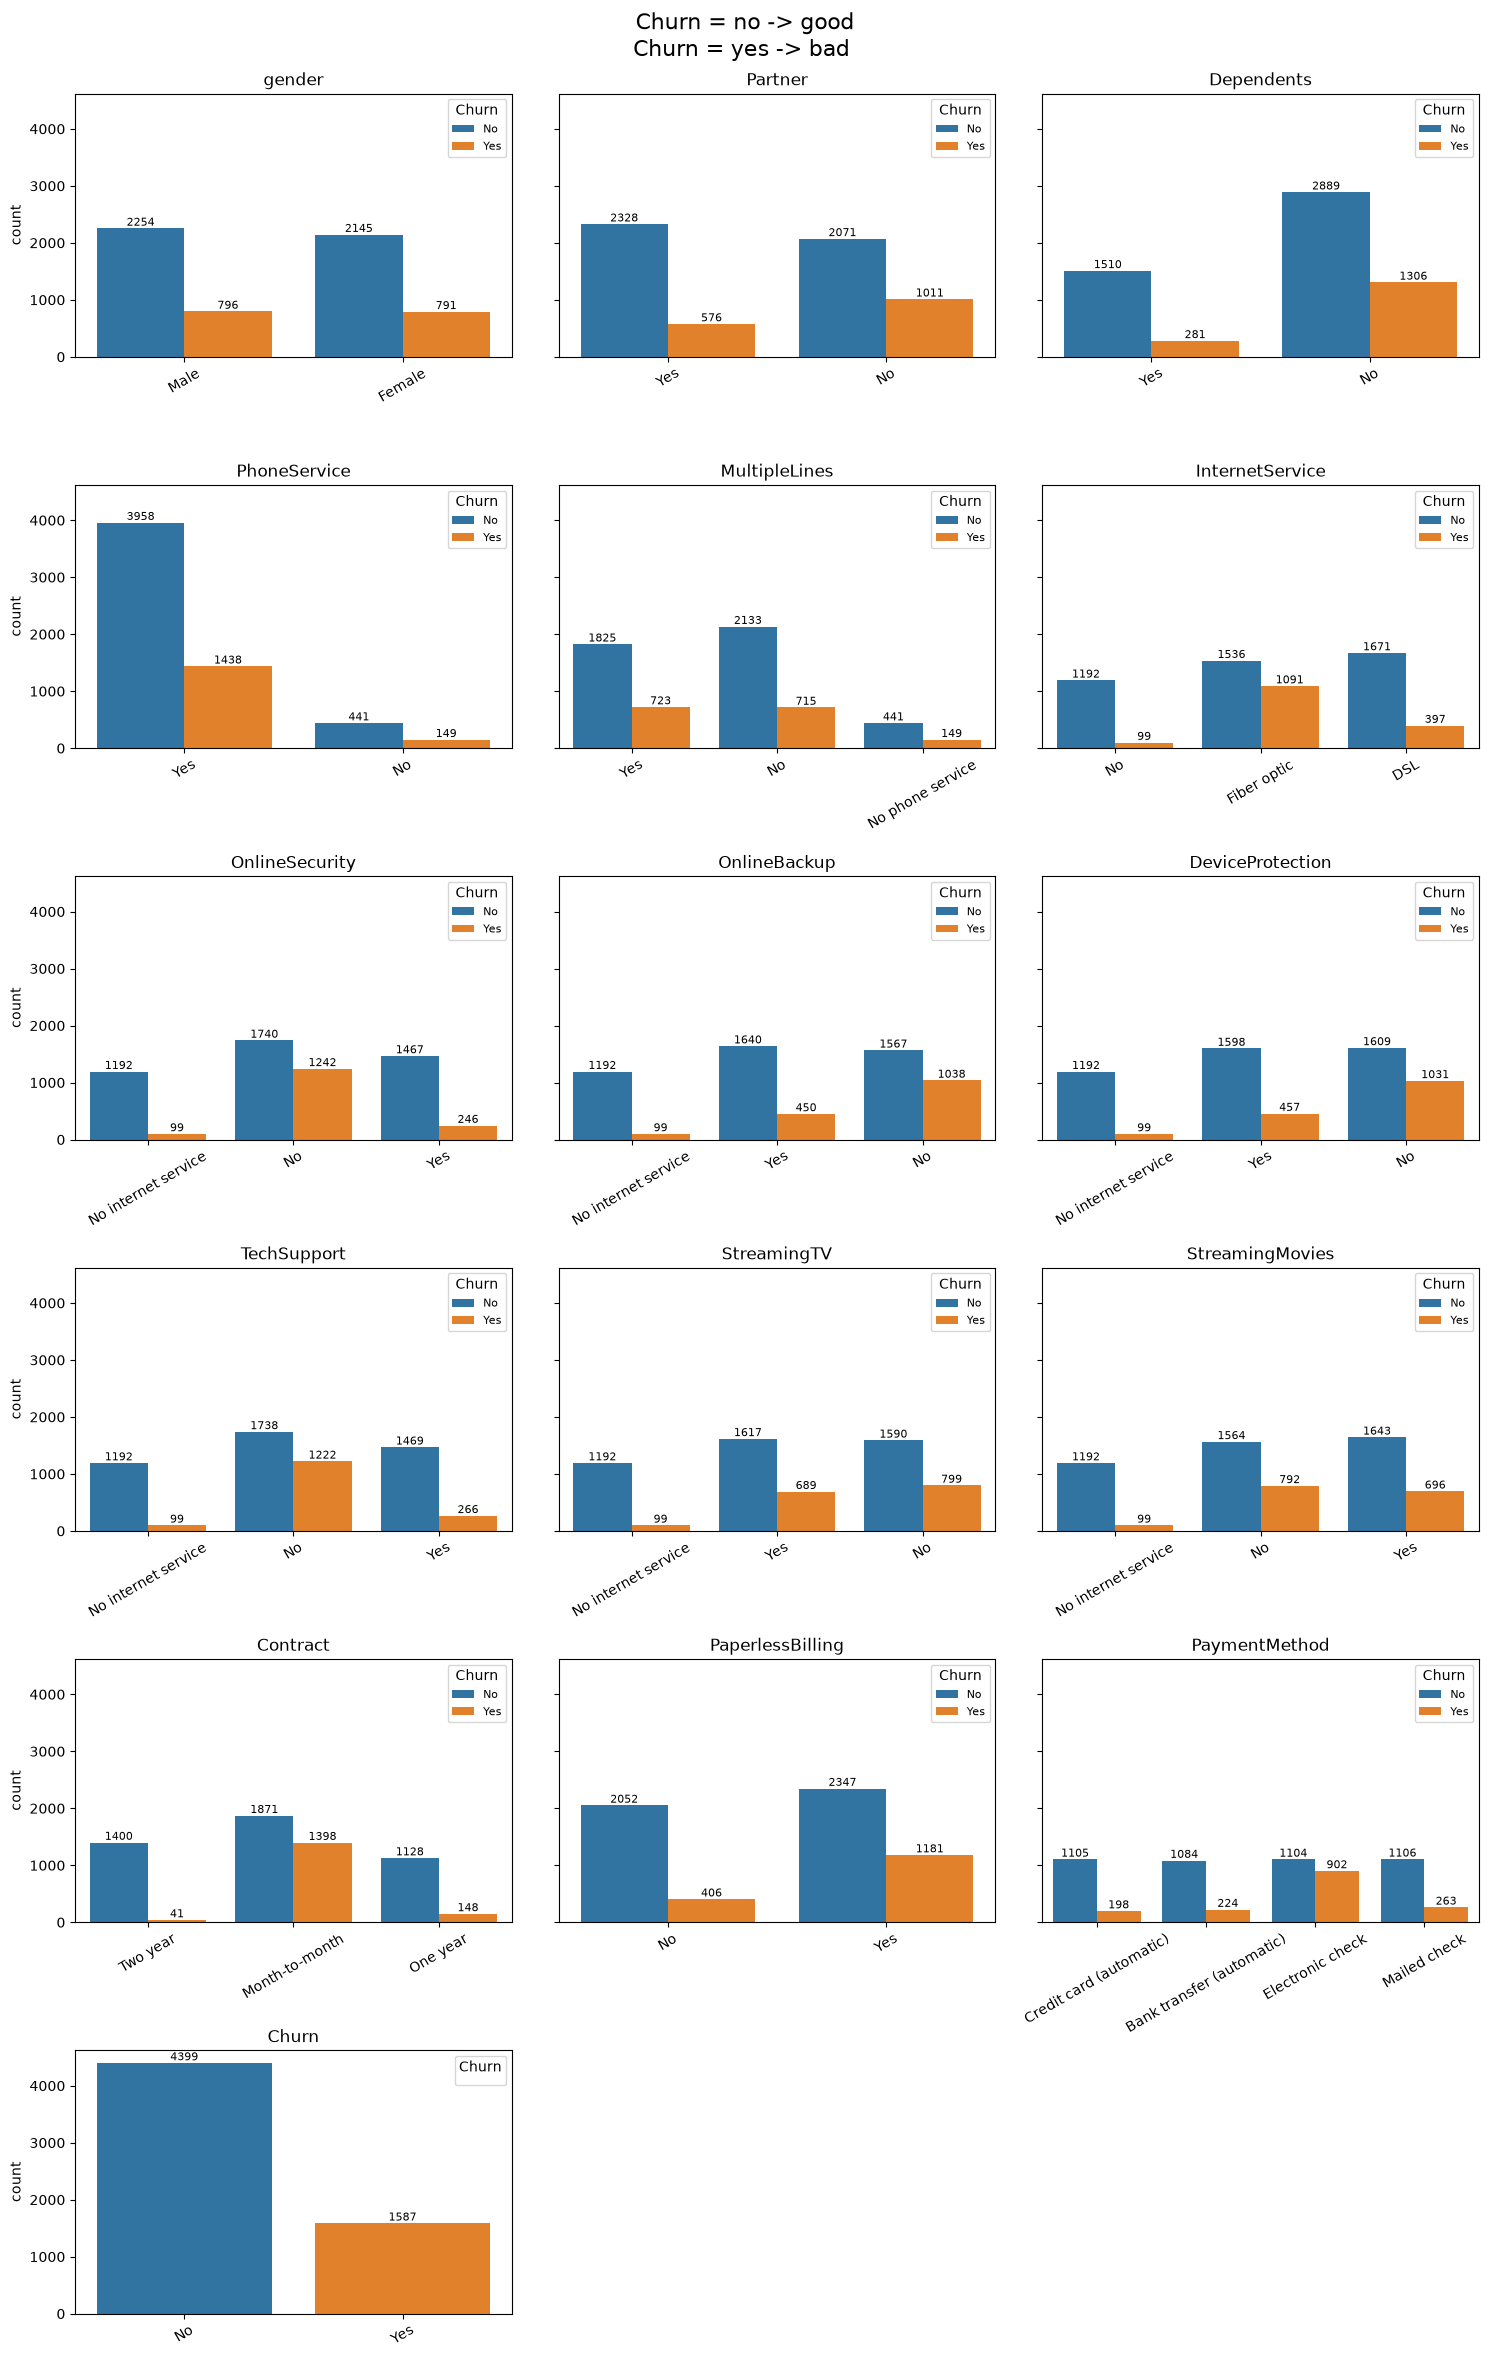

In [40]:
import math
ncols = 3
nrows = math.ceil(len(cat_features) / ncols)  # cat_features = your list of categorical columns
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True, squeeze=False)

for ax, c in zip(axes.flat, cat_features):
    sns.countplot(data=df, x=c, hue="Churn", hue_order=["No", "Yes"], ax=ax)
    for cont in ax.containers:
        ax.bar_label(cont, fontsize=8)          # exact count on each bar
    ax.set_title(c)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Churn", fontsize=8)

for ax in axes.flat[len(cat_features):]:        # hide unused panels
    ax.axis("off")
fig.suptitle("""Churn = no -> good
Churn = yes -> bad 
""", fontsize=16) #(title={"text":"Sepal length vs sepal width", 'x':0.5, 'xanchor':'center'}, font=dict(size=20))
plt.tight_layout()
plt.show()

## Always do clustering after data splitting.

## 4. Splitting the data
With limited amount of data (<1000) it is usually better to do the split with smaller split size (10%).

In [265]:
X = df.drop(columns=['Churn'])
y = df['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #Stratify makes sure that the split of the data will have the same proportion of the "y" variable as the original dataset. Basically the next line of code for the proportion checking becomes unnecessary. "y" referes to the column and not to "yes"!!
X_train.shape, X_test.shape

((4788, 19), (1198, 19))

In [308]:
print(y_train.value_counts(normalize=True), y_test.value_counts(normalize=True))

Churn
No     0.734962
Yes    0.265038
Name: proportion, dtype: float64 Churn
No     0.734558
Yes    0.265442
Name: proportion, dtype: float64


# 5. Training 



## Separate categorical and numeric columns

We will need to treat these features separately just like before

In [266]:
categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()


## Define Categorical and Numerical Transformer Pipeline

Tranformation of the categorical features:

- Constant imputer (SimpleImputer) to fill missing values
- One-hot encoder to get dummy variables

Tranformation of the categorical features:

- Standard Scaler to scale the numeric features
- K-nearest neighbor imputer to fill missing values

Processor: tranform all the features in sequence

- Numeric Transfomer defined earlier
- Categorical Transfomer defined earlier

In [267]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("scaler", StandardScaler().set_output(transform="pandas")),
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) #This is in here to fill in NaN-s because some model would crush on missing vales. 
                                      ])

preprocessor = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

# Clustering

In [46]:
from sklearn.cluster import KMeans

cluster_errors = []

for n_clusters in range(1, 15):
    kmeans_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("scaler", StandardScaler()),
        ("cluster", KMeans(n_clusters=n_clusters, random_state=42, verbose=0))])
    kmeans_pipeline.fit(X_train)
    #kmeans_pipeline.predict(df)
    wcsse = kmeans_pipeline.named_steps["cluster"].inertia_
    print('K = ', n_clusters, '\tWCSS Err. = ', wcsse)
    cluster_errors.append(wcsse)

K =  1 	WCSS Err. =  215459.99999999997
K =  2 	WCSS Err. =  196992.28355359117
K =  3 	WCSS Err. =  144724.3305708124
K =  4 	WCSS Err. =  126829.70301506134
K =  5 	WCSS Err. =  120921.14165374271
K =  6 	WCSS Err. =  116608.07105878663
K =  7 	WCSS Err. =  114216.4121818371
K =  8 	WCSS Err. =  110263.27805889075
K =  9 	WCSS Err. =  108096.28988342546
K =  10 	WCSS Err. =  105665.00612114022
K =  11 	WCSS Err. =  104805.9594935131
K =  12 	WCSS Err. =  103642.30249163246
K =  13 	WCSS Err. =  102263.80052720555
K =  14 	WCSS Err. =  100132.11102147188


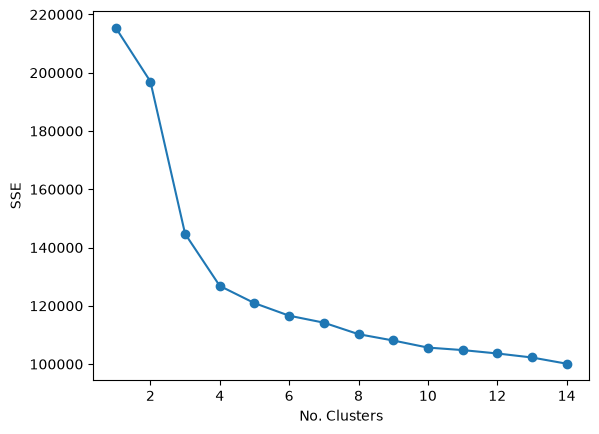

In [47]:
plt.plot(range(1, 15), cluster_errors, "o-")
plt.xlabel("No. Clusters")
plt.ylabel("SSE")
plt.show()

In [63]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score

silhouette_s = []
X_pre = preprocessor.fit_transform(X_train)

for n_clusters in range(2, 11):
    agglo_pipeline = Pipeline([
    #("preprocessor", preprocessor),
    ("scaler", StandardScaler()),
    ("cluster", AgglomerativeClustering(n_clusters=n_clusters))])

    cluster_labels = agglo_pipeline.fit_predict(X_pre)
    print("For n_clusters =", n_clusters,"The average silhouette_score is :", silhouette_score(X_pre, cluster_labels))
    silhouette_s.append(silhouette_score(X_pre, cluster_labels))



For n_clusters = 2 The average silhouette_score is : 0.2377151409312427
For n_clusters = 3 The average silhouette_score is : 0.18103939464334548
For n_clusters = 4 The average silhouette_score is : 0.19916626749175628
For n_clusters = 5 The average silhouette_score is : 0.168508094349372
For n_clusters = 6 The average silhouette_score is : 0.16355708081023307
For n_clusters = 7 The average silhouette_score is : 0.12474023297295432
For n_clusters = 8 The average silhouette_score is : 0.07253910164131423
For n_clusters = 9 The average silhouette_score is : 0.06461099398205279
For n_clusters = 10 The average silhouette_score is : 0.06883608691212759


For n_clusters = 2 The average silhouette_score is : 0.16799424242953986
For n_clusters = 3 The average silhouette_score is : 0.2657370784209863
For n_clusters = 4 The average silhouette_score is : 0.2256408559618259
For n_clusters = 5 The average silhouette_score is : 0.1927168396563171
For n_clusters = 6 The average silhouette_score is : 0.18131821387829972
For n_clusters = 7 The average silhouette_score is : 0.173831981779502
For n_clusters = 8 The average silhouette_score is : 0.11635739140897645
For n_clusters = 9 The average silhouette_score is : 0.11312460582206593
For n_clusters = 10 The average silhouette_score is : 0.11417625067047783




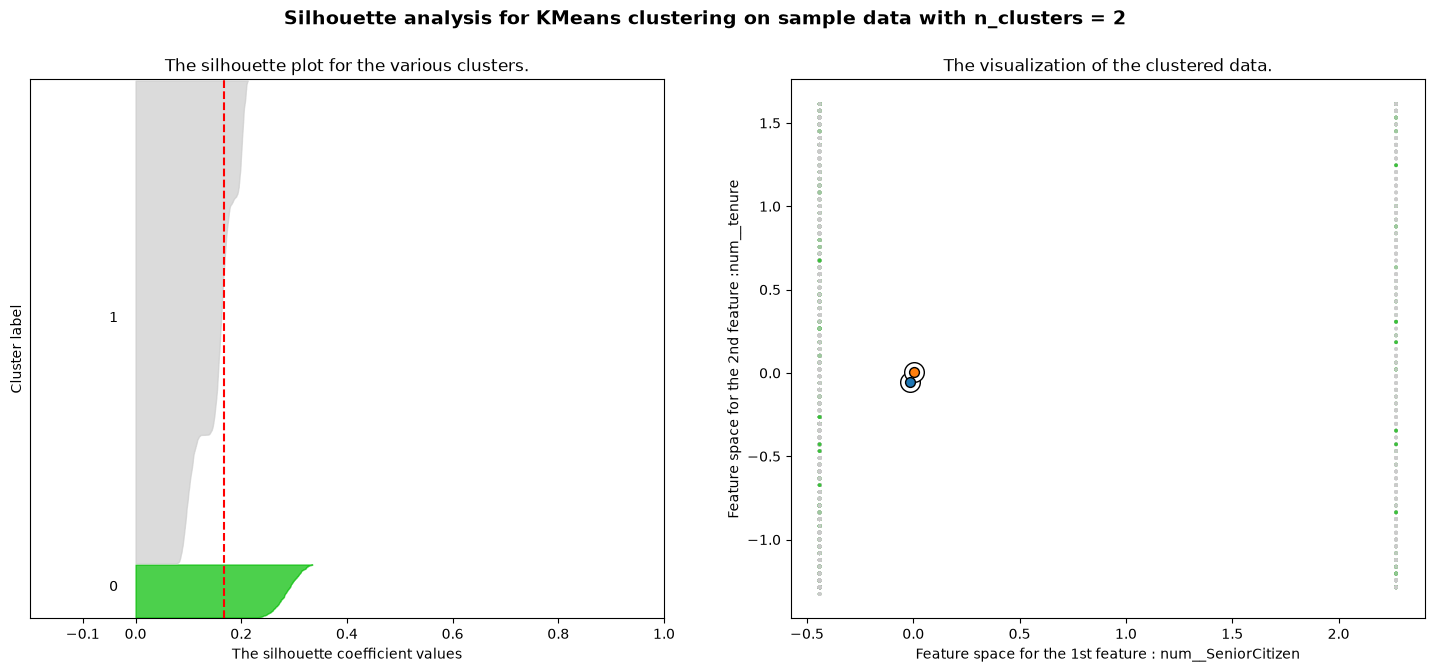

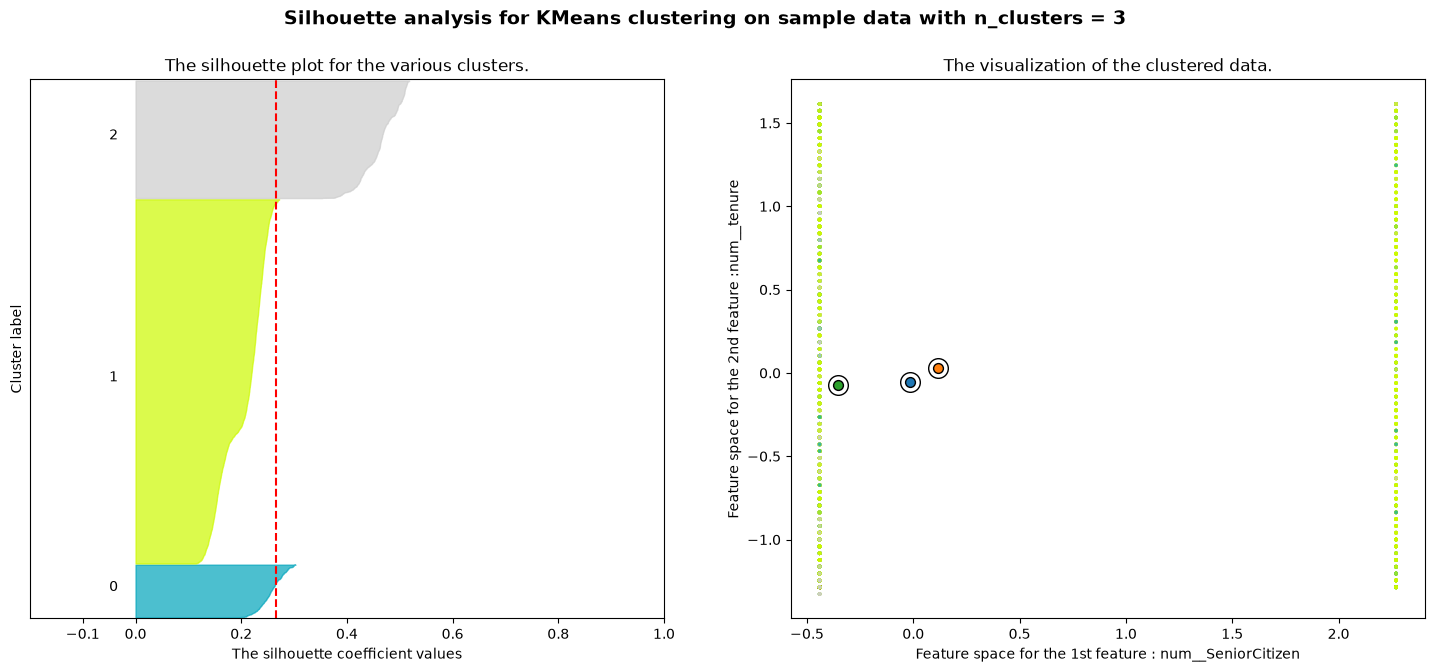

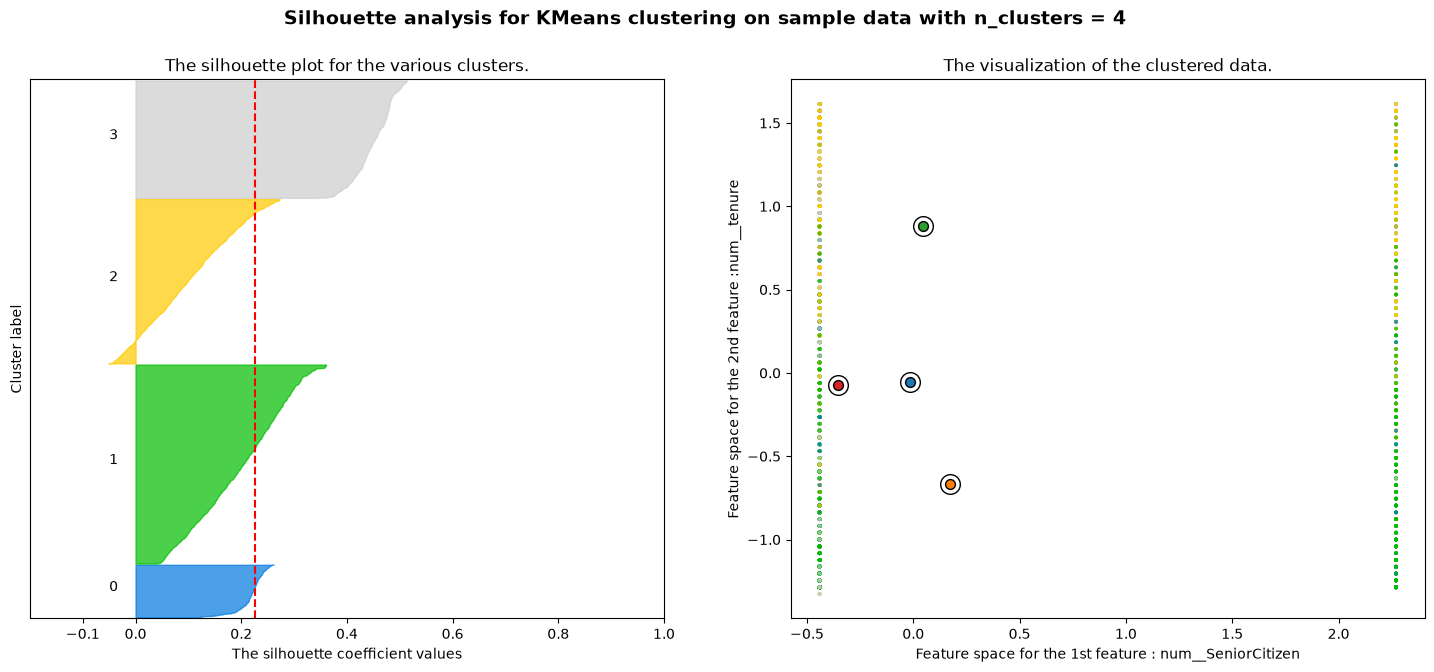

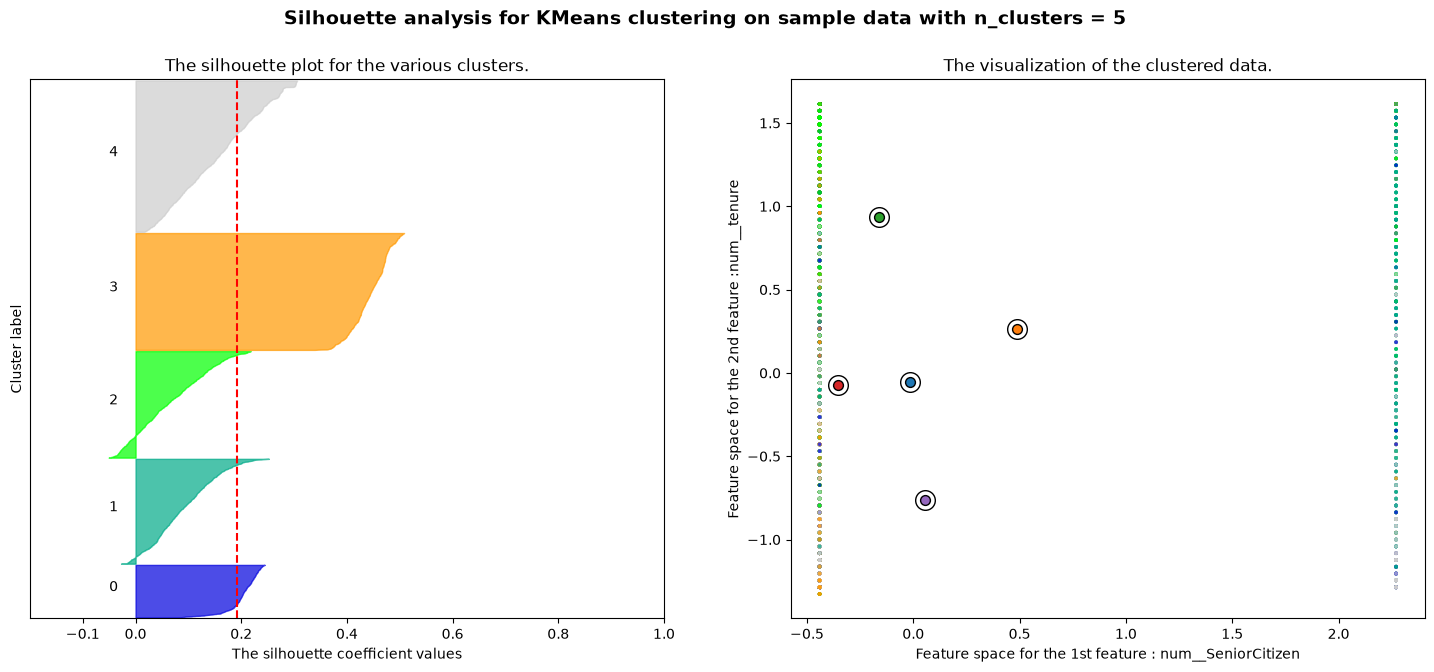

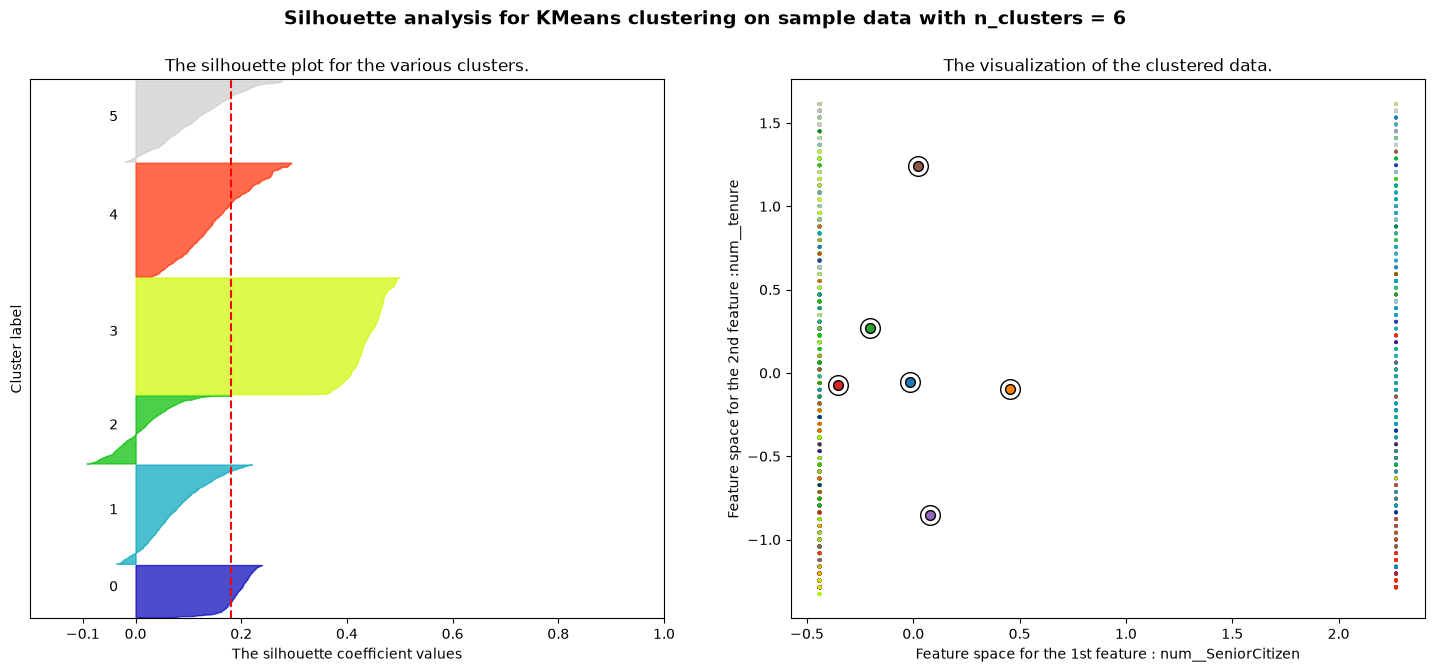

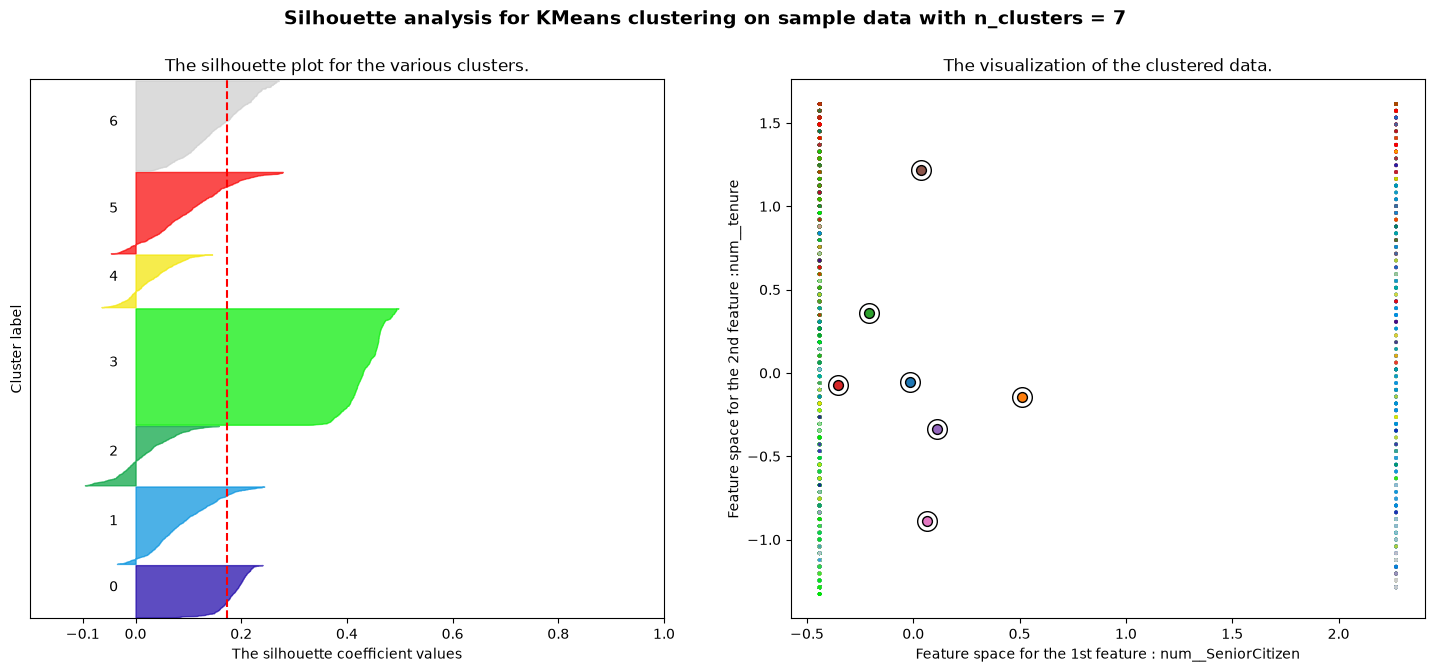

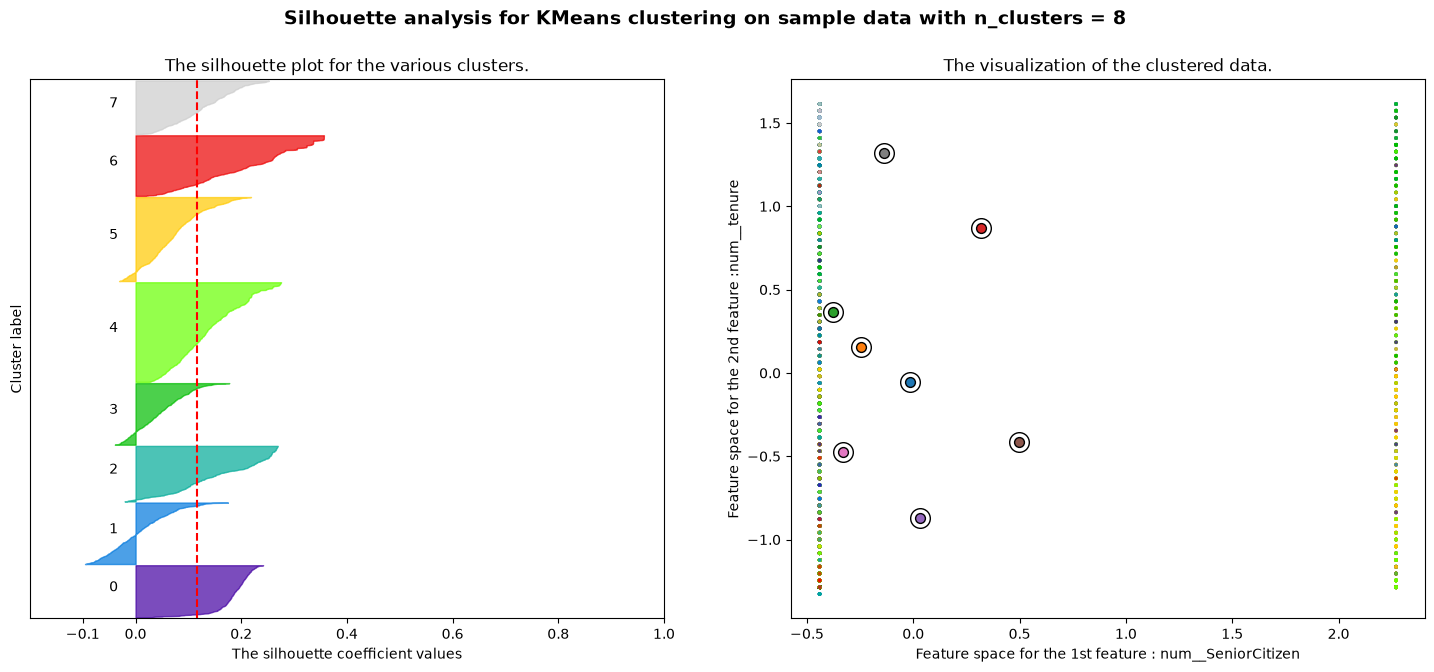

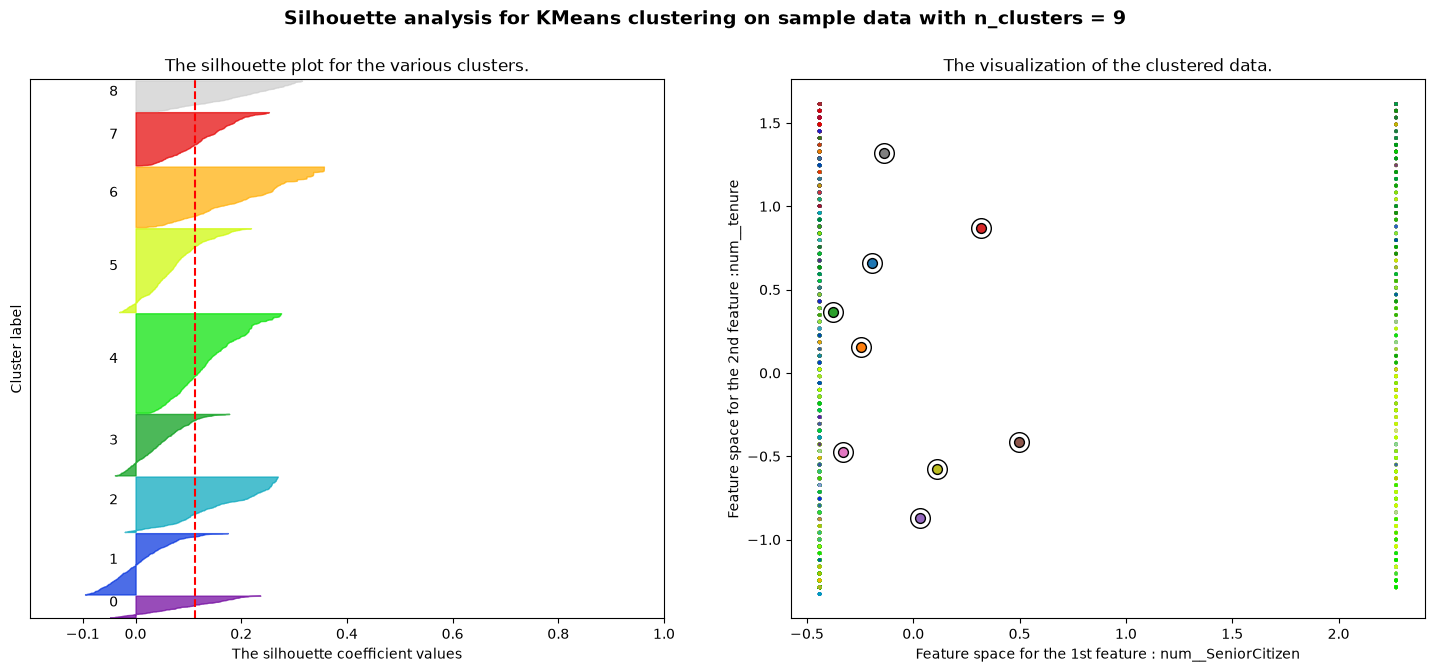

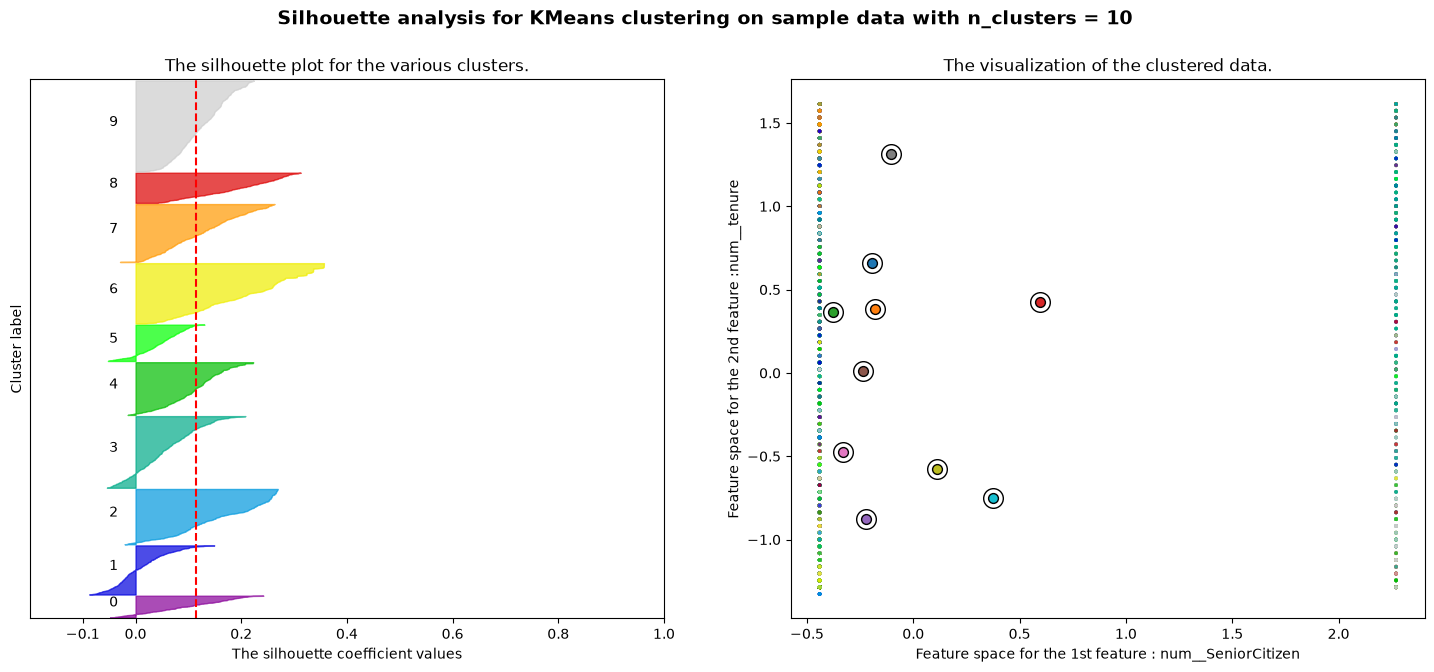

In [64]:
import matplotlib.cm as cm
range_n_clusters = range(2, 11)

X_pre = preprocessor.fit_transform(X_train) 
r_seed = 42
X = X_pre
cols = X.columns
X = X.values #the plot needs a NumPy array that is why we have to do this line

for n_clusters in range_n_clusters:

    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot

    # The silhouette coefficient can range from -1, 1 but in this example all lie within [-0.2, 1]
    ax1.set_xlim([-0.2, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the Pipeline with n_clusters value and a random generator seed for reproducibility.
    kmeans_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("cluster", KMeans(n_clusters=n_clusters, random_state=r_seed, verbose=0))])

    cluster_labels = kmeans_pipeline.fit_predict(X)

    X_scaled = kmeans_pipeline.named_steps["scaler"].transform(X) # apparently since we are scaling KMeans we have to scale also for the sihlouette calculations
    
    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed clusters
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print("For n_clusters =",
          n_clusters,
          "The average silhouette_score is :",
          silhouette_avg)

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i + 1) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0,
                          ith_cluster_silhouette_values,
                          facecolor=color,
                          edgecolor=color,
                          alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral((cluster_labels.astype(float) + 1) / n_clusters)
    ax2.scatter(X[:, 0],
                X[:, 1],
                marker=".",
                s=30,
                lw=0,
                alpha=0.7,
                c=colors,
                edgecolor="k")

    # Labeling the clusters
    pipeline_centers = kmeans_pipeline.named_steps["cluster"].cluster_centers_
    centers = kmeans_pipeline.named_steps["scaler"].inverse_transform(pipeline_centers)
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature : " + cols[0])
    ax2.set_ylabel("Feature space for the 2nd feature :" + cols[1])

    plt.suptitle(
        (
            "Silhouette analysis for KMeans clustering on sample data "
            "with n_clusters = %d" % n_clusters
        ),
        fontsize=14,
        fontweight="bold",
    )
print("\n")
plt.show()

# Splitting by subgroups

In [65]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,Female,0,No,No,44,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.20,No
2,Female,1,Yes,No,38,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,Male,0,No,No,4,Yes,No,DSL,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.50,No
4,Male,0,No,No,2,Yes,No,DSL,Yes,No,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.50,No


In [67]:
df_int = df[df["InternetService"] != "No"]
df_int["InternetService"].value_counts()

InternetService
Fiber optic    2627
DSL            2068
Name: count, dtype: int64

In [313]:
df_int.shape

(4695, 20)

In [312]:
df_no_int = df[df["InternetService"] == "No"]
df_no_int.shape

(1291, 20)

In [72]:
for col in df_no_int.columns:
    print(f"\n{col}:")
    print(df_no_int[col].nunique(dropna=False))


gender:
2

SeniorCitizen:
2

Partner:
2

Dependents:
2

tenure:
73

PhoneService:
1

MultipleLines:
2

InternetService:
1

OnlineSecurity:
1

OnlineBackup:
1

DeviceProtection:
1

TechSupport:
1

StreamingTV:
1

StreamingMovies:
1

Contract:
3

PaperlessBilling:
2

PaymentMethod:
4

MonthlyCharges:
120

TotalCharges:
1189

Churn:
2


In [311]:
const_cols = []
for col in df_no_int.columns:
    if df_no_int[col].nunique(dropna=False) == 1:
        const_cols.append(col)

df_no_int2 = df_no_int.drop(columns=const_cols)
df_no_int2.shape

(1291, 12)

# Run it after the regular data is done!

In [224]:
X = df_int.drop(columns=['Churn'])
y = df_int['Churn']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #Stratify makes sure that the split of the data will have the same proportion of the "y" variable as the original dataset. Basically the next line of code for the proportion checking becomes unnecessary. "y" referes to the column and not to "yes"!!

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()


## Logistic Regression Modeling Pipeline

Chains the following steps:

- Preprocessing pipeline steps defined earlier (categorical to numerical encoding, scaling, filling NaNs)
- Logistic Regression model 

## Train and Evaluate Logistic Regression ML Pipeline



In [268]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline(steps=[
                              ("pre_process", preprocessor),
                              ("model", LogisticRegression(random_state=42, solver='liblinear'))
                              ])


pipeline_lr.fit(X_train, y_train)
y_pred = pipeline_lr.predict(X_test)

class_labels = pipeline_lr.named_steps['model'].classes_ #I do not know what is the purpose of these class lables. 

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)


              precision    recall  f1-score   support

          No       0.83      0.89      0.86       880
         Yes       0.63      0.50      0.56       318

    accuracy                           0.79      1198
   macro avg       0.73      0.70      0.71      1198
weighted avg       0.78      0.79      0.78      1198



,No,Yes
No,785,95
Yes,158,160


In [269]:
scores = {}
scores['log_reg'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781}

## Train and Evaluate K Nearest Neighbors (KNN) ML Pipeline


In [272]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
pipeline_knn = Pipeline([("pre_process", preprocessor),
                            ("model", KNeighborsClassifier(n_neighbors=11))])

pipeline_knn.fit(X_train, y_train)
y_pred = pipeline_knn.predict(X_test)

class_labels = pipeline_knn.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.84      0.85      0.84       880
         Yes       0.57      0.57      0.57       318

    accuracy                           0.77      1198
   macro avg       0.71      0.71      0.71      1198
weighted avg       0.77      0.77      0.77      1198



,No,Yes
No,744,136
Yes,138,180


In [273]:
scores['knn'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781, 'knn': 0.771}

## Train and Evaluate SVM ML Pipeline


In [274]:
from sklearn.svm import LinearSVC
pipeline_svc = Pipeline([("pre_process", preprocessor),
                         ("model", LinearSVC(random_state=42, max_iter=10000))])


pipeline_svc.fit(X_train, y_train)
y_pred = pipeline_svc.predict(X_test)

class_labels = pipeline_svc.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.90      0.86       880
         Yes       0.63      0.50      0.56       318

    accuracy                           0.79      1198
   macro avg       0.73      0.70      0.71      1198
weighted avg       0.78      0.79      0.78      1198



,No,Yes
No,788,92
Yes,160,158


In [275]:
scores['svm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781, 'knn': 0.771, 'svm': 0.781}

## Train and Evaluate Naive Bayes ML Pipeline
This model does not need scaling.
MultinomialNB / ComplementNB would crash after standardization, given the negative values.

Which distribution to use:
- BernoulliNB assumes binary (0/1) features. By default it binarises every feature at binarize=0.0, so with continuous, all-positive data nearly everything becomes 1 and the model loses most of the information.
- GaussianNB is the one for continuous numeric features. 
- MultinomialNB is for counts, like word frequencies.

In [276]:
categorical_transformer = Pipeline(steps=[
                                          ("cat_imputer", SimpleImputer(strategy='constant',
                                                                        fill_value='Not Available').set_output(transform="pandas")),
                                          ("onehot", OneHotEncoder(sparse_output=False,
                                                                   handle_unknown="ignore").set_output(transform="pandas"))
                                          ])

numeric_transformer = Pipeline(steps=[
                                      ("knn_imputer", KNNImputer(n_neighbors=5).set_output(transform="pandas")) # no standard scaling for numeric data
                                      ]) #see there is no scaler here

preprocessor_new = ColumnTransformer(transformers=[
                                               ("num", numeric_transformer,
                                                       numeric_features),
                                               ("cat", categorical_transformer,
                                                       categorical_features)
                                               ]).set_output(transform="pandas")

In [277]:
from sklearn.naive_bayes import BernoulliNB

pipeline_nb = Pipeline([("pre_process", preprocessor_new),
                         ("model", BernoulliNB())
                         ])

pipeline_nb.fit(X_train, y_train)
y_pred = pipeline_nb.predict(X_test)

class_labels = pipeline_nb.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.89      0.67      0.76       880
         Yes       0.45      0.76      0.57       318

    accuracy                           0.69      1198
   macro avg       0.67      0.71      0.66      1198
weighted avg       0.77      0.69      0.71      1198



,No,Yes
No,586,294
Yes,76,242


In [278]:
scores['nb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781, 'knn': 0.771, 'svm': 0.781, 'nb': 0.709}

## Tree-based models don't require data to be scaled - hence the new processer is used down the line.

Tree based models are non-linear and are not distance based models. Hence we will create a new transformation pipeline without scaling

## Train and Evaluate Decision Tree ML Pipeline


In [279]:
from sklearn.tree import DecisionTreeClassifier
pipeline_dtree = Pipeline([("pre_process", preprocessor_new),
                         ("model", DecisionTreeClassifier(random_state=42))])


pipeline_dtree.fit(X_train, y_train)
y_pred = pipeline_dtree.predict(X_test)

class_labels = pipeline_dtree.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.81      0.78      0.80       880
         Yes       0.46      0.51      0.48       318

    accuracy                           0.71      1198
   macro avg       0.64      0.65      0.64      1198
weighted avg       0.72      0.71      0.71      1198



,No,Yes
No,687,193
Yes,156,162


In [280]:
scores['dtree'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781, 'knn': 0.771, 'svm': 0.781, 'nb': 0.709, 'dtree': 0.714}

## Train and Evaluate Random Forest ML Pipeline


In [281]:
from sklearn.ensemble import RandomForestClassifier
pipeline_rf = Pipeline([("pre_process", preprocessor_new),
                         ("model", RandomForestClassifier(random_state=42))])

pipeline_rf.fit(X_train, y_train)
y_pred = pipeline_rf.predict(X_test)

class_labels = pipeline_rf.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.82      0.89      0.85       880
         Yes       0.60      0.47      0.53       318

    accuracy                           0.78      1198
   macro avg       0.71      0.68      0.69      1198
weighted avg       0.76      0.78      0.77      1198



,No,Yes
No,781,99
Yes,169,149


In [282]:
scores['rf'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781,
 'knn': 0.771,
 'svm': 0.781,
 'nb': 0.709,
 'dtree': 0.714,
 'rf': 0.767}

## Train and Evaluate AdaBoost ML Pipeline


In [283]:
from sklearn.ensemble import AdaBoostClassifier

pipeline_ada_boost = Pipeline([("pre_process", preprocessor_new),
                         ("model", AdaBoostClassifier(random_state=42))])


pipeline_ada_boost.fit(X_train, y_train)
y_pred = pipeline_ada_boost.predict(X_test)

class_labels = pipeline_ada_boost.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.89      0.86       880
         Yes       0.62      0.49      0.55       318

    accuracy                           0.78      1198
   macro avg       0.72      0.69      0.70      1198
weighted avg       0.77      0.78      0.78      1198



,No,Yes
No,783,97
Yes,161,157


In [284]:
scores['ada_boost'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781,
 'knn': 0.771,
 'svm': 0.781,
 'nb': 0.709,
 'dtree': 0.714,
 'rf': 0.767,
 'ada_boost': 0.776}

## Train and Evaluate Gradient Boosting ML Pipeline


In [285]:
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gbm = Pipeline([("pre_process", preprocessor_new),
                         ("model", GradientBoostingClassifier(random_state=42))])


pipeline_gbm.fit(X_train, y_train)
y_pred = pipeline_gbm.predict(X_test)

class_labels = pipeline_gbm.named_steps['model'].classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.84      0.90      0.87       880
         Yes       0.66      0.52      0.58       318

    accuracy                           0.80      1198
   macro avg       0.75      0.71      0.72      1198
weighted avg       0.79      0.80      0.79      1198



,No,Yes
No,795,85
Yes,154,164


In [286]:
scores['gbm'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781,
 'knn': 0.771,
 'svm': 0.781,
 'nb': 0.709,
 'dtree': 0.714,
 'rf': 0.767,
 'ada_boost': 0.776,
 'gbm': 0.792}

## Train and Evaluate Extreme Gradient Boosting (XGBoost) ML Pipeline


In [287]:
from xgboost import XGBClassifier
pipeline_xgb = Pipeline([("pre_process", preprocessor_new),
                         ("model", XGBClassifier(random_state=42))])



In [288]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# transform y labels into 0 and 1 as latest xgboost version doesn't support string labels
y_train_le = le.fit_transform(y_train)
y_test_le = le.transform(y_test)

In [289]:
pipeline_xgb.fit(X_train, y_train_le)
y_pred_le = pipeline_xgb.predict(X_test)

In [290]:
y_pred = le.inverse_transform(y_pred_le)

In [291]:
class_labels = le.classes_

print(classification_report(y_test, y_pred))

pd.DataFrame(confusion_matrix(y_test, y_pred),
             columns=class_labels, index=class_labels)

              precision    recall  f1-score   support

          No       0.83      0.88      0.85       880
         Yes       0.60      0.50      0.55       318

    accuracy                           0.78      1198
   macro avg       0.71      0.69      0.70      1198
weighted avg       0.77      0.78      0.77      1198



,No,Yes
No,772,108
Yes,158,160


In [292]:
scores['xgb'] = round(f1_score(y_test, y_pred, average='weighted'), 3)
scores

{'log_reg': 0.781,
 'knn': 0.771,
 'svm': 0.781,
 'nb': 0.709,
 'dtree': 0.714,
 'rf': 0.767,
 'ada_boost': 0.776,
 'gbm': 0.792,
 'xgb': 0.772}

## Compare model performances

In [293]:
result = pd.DataFrame({
    "Model" : scores.keys(),
    'F1-Score': scores.values()
})

result

,Model,F1-Score
0,log_reg,0.781
1,knn,0.771
2,svm,0.781
3,nb,0.709
4,dtree,0.714
5,rf,0.767
6,ada_boost,0.776
7,gbm,0.792
8,xgb,0.772


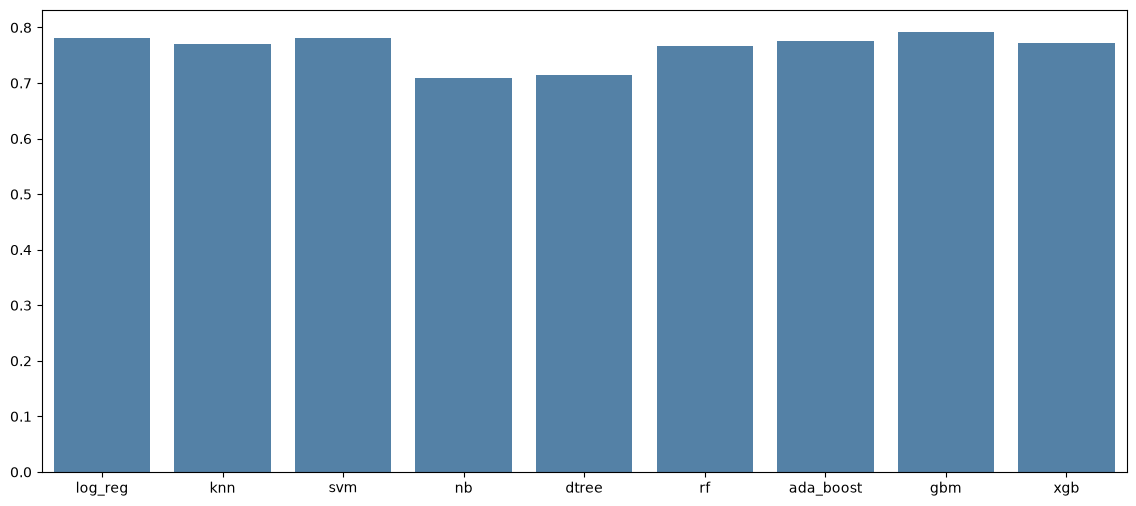

In [294]:
plt.figure(figsize=(14, 6))
sns.barplot(x=list(scores.keys()),
            y=list(scores.values()), color="Steelblue");

## Feature Importance

Trees based models like RandomForest, XGBoost, etc.  provide us feature importance based on the training.

In [295]:
xgb_model = pipeline_xgb['model']
feature_names = pipeline_xgb['pre_process'].get_feature_names_out()
feature_names

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__PhoneService_No',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__

In [296]:
xgb_model.feature_importances_

array([0.01018179, 0.01233274, 0.00850597, 0.00825122, 0.00643836,
       0.        , 0.00672026, 0.        , 0.0078438 , 0.        ,
       0.02022288, 0.        , 0.01039672, 0.        , 0.0089184 ,
       0.00691343, 0.35527623, 0.00495283, 0.01685055, 0.        ,
       0.00734176, 0.0095891 , 0.        , 0.00571806, 0.00625546,
       0.        , 0.00692602, 0.01935933, 0.        , 0.00749423,
       0.00861637, 0.        , 0.00678386, 0.00956517, 0.        ,
       0.01373359, 0.33454663, 0.01015177, 0.03103767, 0.00954488,
       0.        , 0.00592714, 0.00816886, 0.00973834, 0.00569662],
      dtype=float32)

In [297]:
xgb_importances = pd.DataFrame(
    {"feature": feature_names, "importance": np.round(xgb_model.feature_importances_, 3)}
)
xgb_importances = xgb_importances.sort_values("importance", ascending=False).set_index(
    "feature"
)
xgb_importances.head(20)

,importance
feature,
cat__InternetService_Fiber optic,0.355
cat__Contract_Month-to-month,0.335
cat__Contract_Two year,0.031
cat__PhoneService_No,0.020
cat__TechSupport_No,0.019
cat__OnlineSecurity_No,0.017
cat__StreamingMovies_Yes,0.014
num__tenure,0.012
cat__StreamingMovies_No,0.010


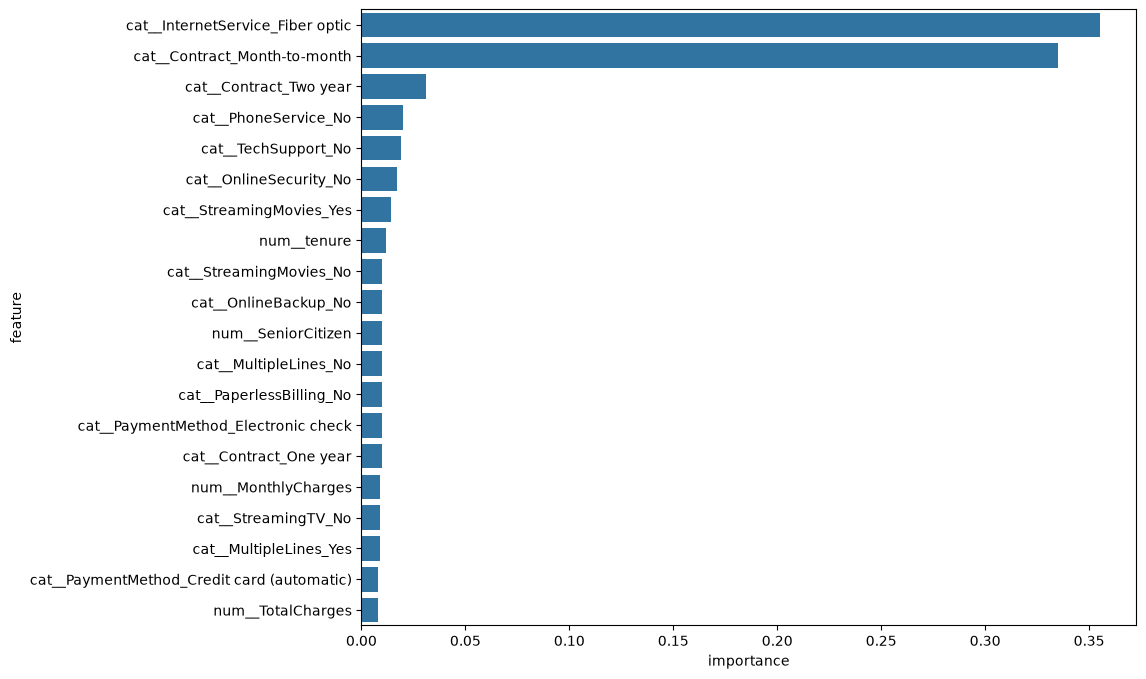

In [298]:
plt.figure(figsize=(10, 8))
sns.barplot(y=xgb_importances.head(20).index,
            x=xgb_importances.head(20).importance);

## Cross-Validation Evaluation and Model Comparison (Optional)

Standard process followed in the industry to compare multiple ML models

In [299]:
from sklearn.model_selection import cross_val_score

#### Cross-Validating based on Average F1 score

In [300]:
cvs = 3
scores_cv = {}
scores_cv['log_reg'] = cross_val_score(pipeline_lr, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['knn'] = cross_val_score(pipeline_knn, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['nb'] = cross_val_score(pipeline_nb, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['svm'] = cross_val_score(pipeline_svc, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['dtree'] = cross_val_score(pipeline_dtree, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['rf'] = cross_val_score(pipeline_rf, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['ada_boost'] = cross_val_score(pipeline_ada_boost, X_train, y_train, cv=cvs, scoring='f1_weighted')
scores_cv['gbm'] = cross_val_score(pipeline_gbm, X_train, y_train, cv=cvs, scoring='f1_weighted')
# here labels need to be used as 0 and 1 which are label encoded
scores_cv['xgb'] = cross_val_score(pipeline_xgb, X_train, y_train_le, cv=cvs, scoring='f1_weighted')

In [301]:
result = pd.DataFrame({
    "Model" : scores_cv.keys(),
    'F1-Score': [round(np.mean(scores), 3) for scores in scores_cv.values()]
})

result.sort_values("F1-Score", ascending=False)

,Model,F1-Score
0,log_reg,0.798
3,svm,0.794
6,ada_boost,0.793
7,gbm,0.793
1,knn,0.784
8,xgb,0.778
5,rf,0.777
4,dtree,0.742
2,nb,0.737


In [302]:
from flaml import AutoML

automl = AutoML()

automl_settings = {
    "time_budget": 600, # 10 mins to try and select the best model
    "metric": 'macro_f1', #if it is only f1, then it expect a binary classification. Macro averages it out....
    "task": 'classification',
    "log_file_name": 'mylog.log',
    #"estimator_list": ["xgboost", "catboost", "rf", "extra_tree"], #needs to check if I need this row or not
    "seed": 42
}
automl.fit(X_train=X_train, y_train=y_train_le, # ensemble=True, if we add this, then it would combine the best models into a final model. It takes more computing, and makes the model less explainable. 
           **automl_settings)

[flaml.automl.logger: 10-01 16:18:42] {2470} INFO - task = classification
[flaml.automl.logger: 10-01 16:18:42] {2481} INFO - Evaluation method: cv
[flaml.automl.logger: 10-01 16:18:42] {2584} INFO - Minimizing error metric: 1-macro_f1
[flaml.automl.logger: 10-01 16:18:42] {2701} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 10-01 16:18:42] {3006} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 10-01 16:18:42] {3141} INFO - Estimated sufficient time budget=3252s. Estimated necessary time budget=80s.
[flaml.automl.logger: 10-01 16:18:42] {3192} INFO -  at 0.5s,	estimator lgbm's best error=5.7638e-01,	best estimator lgbm's best error=5.7638e-01
[flaml.automl.logger: 10-01 16:18:42] {3006} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 10-01 16:18:42] {3192} INFO -  at 0.9s,	estimator lgbm's best error=5.7638e-01,	best estimator lgbm's best error=5.7638e-01

c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[flaml.automl.logger: 10-01 16:26:26] {3192} INFO -  at 464.5s,	estimator lrl1's best error=3.1380e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:26:26] {3006} INFO - iteration 248, current learner lrl1


c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[flaml.automl.logger: 10-01 16:26:27] {3192} INFO -  at 466.0s,	estimator lrl1's best error=3.1380e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:26:27] {3006} INFO - iteration 249, current learner lrl1


...

[flaml.automl.logger: 10-01 16:28:33] {3192} INFO -  at 591.4s,	estimator lrl1's best error=3.1380e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:28:33] {3006} INFO - iteration 310, current learner lrl1


c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[flaml.automl.logger: 10-01 16:28:34] {3192} INFO -  at 592.8s,	estimator lrl1's best error=3.1380e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:28:34] {3006} INFO - iteration 311, current learner sgd


c:\Users\danik\miniconda3\envs\GC2\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[flaml.automl.logger: 10-01 16:28:34] {3192} INFO -  at 593.1s,	estimator sgd's best error=3.2454e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:28:35] {3006} INFO - iteration 312, current learner rf
[flaml.automl.logger: 10-01 16:28:35] {3192} INFO -  at 593.8s,	estimator rf's best error=2.7680e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:28:35] {3006} INFO - iteration 313, current learner xgb_limitdepth
[flaml.automl.logger: 10-01 16:28:40] {3192} INFO -  at 598.6s,	estimator xgb_limitdepth's best error=2.5894e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:28:40] {3006} INFO - iteration 314, current learner rf
[flaml.automl.logger: 10-01 16:28:41] {3192} INFO -  at 599.2s,	estimator rf's best error=2.7680e-01,	best estimator xgb_limitdepth's best error=2.5894e-01
[flaml.automl.logger: 10-01 16:28:41] {3006} INFO - iteration 315, current learner lgbm
[flam

In [303]:
automl.best_estimator

'xgb_limitdepth'

In [304]:
automl.best_config

{'n_estimators': 654,
 'max_depth': 2,
 'min_child_weight': np.float64(0.4647948203942593),
 'learning_rate': np.float64(0.12722890798060188),
 'subsample': np.float64(0.8442404358792689),
 'colsample_bylevel': np.float64(0.8582934378476018),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.0202911914724552),
 'reg_lambda': np.float64(241.49725858670791)}

In [305]:
automl.model.get_params()

{'n_estimators': 654,
 'max_depth': 2,
 'min_child_weight': np.float64(0.4647948203942593),
 'learning_rate': np.float64(0.12722890798060188),
 'subsample': np.float64(0.8442404358792689),
 'colsample_bylevel': np.float64(0.8582934378476018),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.0202911914724552),
 'reg_lambda': np.float64(241.49725858670791),
 'n_jobs': -1,
 'verbosity': 0,
 'random_state': 10242048,
 'task': <flaml.automl.task.generic_task.GenericTask at 0x1be094c0d50>,
 '_estimator_type': 'classifier'}

In [306]:
y_pred = automl.predict(X_test)

In [307]:
print(classification_report(y_test_le, y_pred))
f1_score(y_test_le, y_pred, average='weighted')

              precision    recall  f1-score   support

           0       0.84      0.90      0.87       880
           1       0.65      0.51      0.57       318

    accuracy                           0.80      1198
   macro avg       0.74      0.71      0.72      1198
weighted avg       0.79      0.80      0.79      1198



0.7886460250277839

# Results

## Results of the original run, no group sep:

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.798</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.794</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.793</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.784</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.778</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.777</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.742</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.737</td>
    </tr>
  </tbody>
</table>
</div>

model: xgb_limitdepth

precision    recall  f1-score   support

           0       0.84      0.90      0.87       880
           1       0.65      0.51      0.57       318

    accuracy                           0.80      1198
   macro avg       0.74      0.71      0.72      1198
weighted avg       0.79      0.80      0.79      1198

{'n_estimators': 654,
 'max_depth': 2,
 'min_child_weight': np.float64(0.4647948203942593),
 'learning_rate': np.float64(0.12722890798060188),
 'subsample': np.float64(0.8442404358792689),
 'colsample_bylevel': np.float64(0.8582934378476018),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.0202911914724552),
 'reg_lambda': np.float64(241.49725858670791)}

## Predictions of the internet group

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.761</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.758</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.757</td>
    </tr>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.749</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.748</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.735</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.733</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.720</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.692</td>
    </tr>
  </tbody>
</table>
</div>

after 10 min Auto ML

precision    recall  f1-score   support

           0       0.80      0.86      0.83       641
           1       0.64      0.55      0.59       298

    accuracy                           0.76       939
   macro avg       0.72      0.70      0.71       939
weighted avg       0.75      0.76      0.75       939


{'n_estimators': 19,
 'max_depth': 3,
 'min_child_weight': np.float64(0.16278088111539776),
 'learning_rate': 1.0,
 'subsample': np.float64(0.6949725916375937),
 'colsample_bylevel': np.float64(0.914347466686421),
 'colsample_bytree': 1.0,
 'reg_alpha': np.float64(0.017033884749263227),
 'reg_lambda': np.float64(379.2942506687784)}

## Predictions of the no internet group  - very low sample rate
<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Model</th>
      <th>F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>5</th>
      <td>rf</td>
      <td>0.898</td>
    </tr>
    <tr>
      <th>7</th>
      <td>gbm</td>
      <td>0.891</td>
    </tr>
    <tr>
      <th>8</th>
      <td>xgb</td>
      <td>0.888</td>
    </tr>
    <tr>
      <th>0</th>
      <td>log_reg</td>
      <td>0.887</td>
    </tr>
    <tr>
      <th>3</th>
      <td>svm</td>
      <td>0.887</td>
    </tr>
    <tr>
      <th>1</th>
      <td>knn</td>
      <td>0.886</td>
    </tr>
    <tr>
      <th>6</th>
      <td>ada_boost</td>
      <td>0.883</td>
    </tr>
    <tr>
      <th>4</th>
      <td>dtree</td>
      <td>0.873</td>
    </tr>
    <tr>
      <th>2</th>
      <td>nb</td>
      <td>0.860</td>
    </tr>
  </tbody>
</table>
</div>

10 min autoML 
{'penalty': np.str_('elasticnet'),
 'alpha': np.float64(1.0907499681742529e-06),
 'l1_ratio': np.float64(0.08626681209818353),
 'epsilon': np.float64(0.04724875710415196),
 'learning_rate': np.str_('optimal'),
 'eta0': np.float64(0.0035367964690083587),
 'power_t': np.float64(0.5177894669051555),
 'average': False,
 'loss': 'log_loss'}

 model SGD 
 precision    recall  f1-score   support

           0       0.97      0.88      0.92       239
           1       0.32      0.65      0.43        20

    accuracy                           0.86       259
   macro avg       0.64      0.77      0.67       259
weighted avg       0.92      0.86      0.89       259